In [12]:
print("hello world")

hello world


In [13]:
#check version of python
import sys
print(sys.version)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [1]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [8]:
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [9]:
(X_train, y_train), _ = keras.datasets.cifar10.load_data()
print("Tranning data shape:", X_train.shape)
print("Tranning labels shape:", y_train.shape)

c:\Users\Abhisek kundu\Desktop\job_search\tfenv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Tranning data shape: (50000, 32, 32, 3)
Tranning labels shape: (50000, 1)


In [10]:
X_train = X_train / 255.0


In [13]:
datagen = ImageDataGenerator(
    rotation_range = 15,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True,
    zoom_range = 0.1,
    fill_mode = 'nearest'
)

ImportError: This requires the scipy module. You can install it via `pip install scipy`

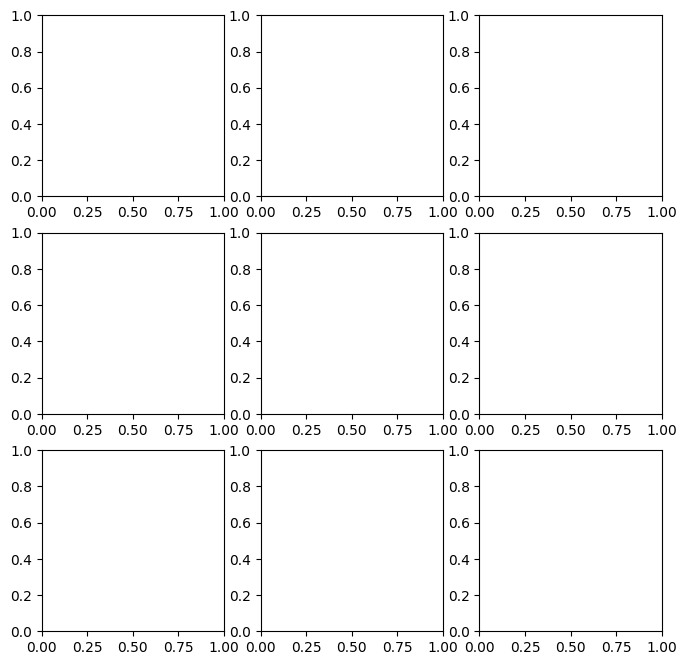

In [16]:
# sample = X_train[:9]
sample = np.expand_dims(X_train[0], axis=0)

fig, axes = plt.subplots(3,3, figsize=(8,8))
for img, ax in zip(datagen.flow(sample, batch_size=9, shuffle=False).__next__(), axes.flat):
    ax.imshow(img)
    ax.axis('off')


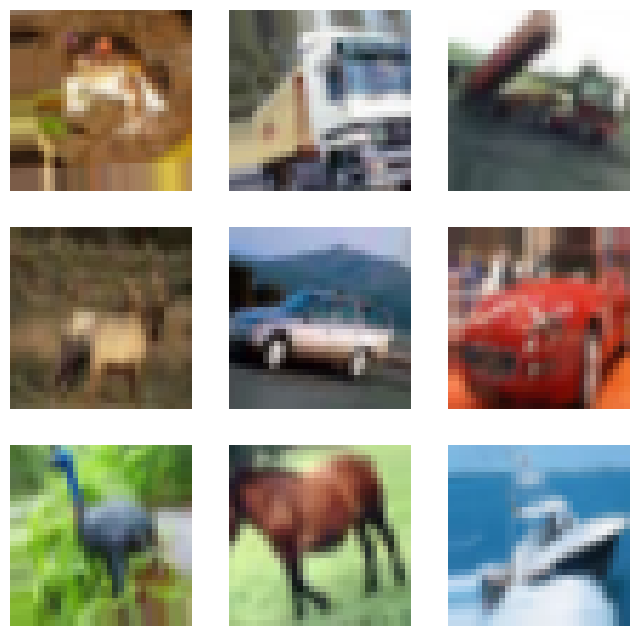

In [19]:
sample = X_train[:9]

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for img, ax in zip(datagen.flow(sample, batch_size=9, shuffle=False).__next__(), axes.flat):
    ax.imshow(img)
    ax.axis("off")

In [24]:
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), input_shape=(32,32,3)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),
    keras.layers.Dense(256),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),

    keras.layers.Dense(10, activation='softmax')
])

In [26]:
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 613,450 (2.34 MB)

 Trainable params: 612,746 (2.34 MB)

 Non-trainable params: 704 (2.75 KB)

None


In [27]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [28]:
#used augmentation in tranning
model.fit(datagen.flow(X_train, y_train, batch_size=32), epochs=30, steps_per_epoch=len(X_train)//32)

Epoch 1/30
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 57s 34ms/step - accuracy: 0.5209 - loss: 1.3405
Epoch 2/30
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 0s 15us/step - accuracy: 0.6250 - loss: 1.0750 
Epoch 3/30


c:\Users\Abhisek kundu\Desktop\job_search\tfenv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 52s 33ms/step - accuracy: 0.6165 - loss: 1.0877
Epoch 4/30
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 0s 10us/step - accuracy: 0.5625 - loss: 1.2234 
Epoch 5/30
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 51s 33ms/step - accuracy: 0.6519 - loss: 0.9881
Epoch 6/30
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 0s 6us/step - accuracy: 0.6875 - loss: 0.9975  
Epoch 7/30
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.6717 - loss: 0.9278
Epoch 8/30
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 0s 15us/step - accuracy: 0.6562 - loss: 0.9862 
Epoch 9/30
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.6931 - loss: 0.8785
Epoch 10/30
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 0s 11us/step - accuracy: 0.7188 - loss: 0.7047 
Epoch 11/30
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.7077 - loss: 0.8363
Epoch 12/30
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 0s 9us/step - accuracy: 0.7812 - loss: 0.7591  
Epoch 13/30
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.7188 - loss: 0.8088
Epoch 14/30
1562/

In [29]:
import numpy as np

# choose one image from the dataset
sample_idx = 0
sample_img = X_train[sample_idx]
sample_label = y_train[sample_idx]

# add batch dimension
input_img = np.expand_dims(sample_img, axis=0)

# predict
pred = model.predict(input_img)
predicted_label = np.argmax(pred, axis=1)[0]

print("True label:     ", sample_label)
print("Predicted label:", predicted_label)
print("Predicted probs:", pred[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
True label:      [6]
Predicted label: 6
Predicted probs: [2.6807433e-05 1.6522837e-04 3.1334430e-03 2.3978636e-02 3.5163318e-03
 5.3296223e-02 9.1252822e-01 3.1358164e-03 1.5867988e-04 6.0543905e-05]
